In [ ]:
# import libraries
import sys
import ipynbname
import matplotlib.pyplot as plt
import seaborn as sns

from astropy.visualization import astropy_mpl_style
from astropy.io import fits
from astropy.time import Time
from pathlib import Path

# Get the absolute path of the current notebook
nb_path = Path(ipynbname.path()).resolve()

ROOT = nb_path.parents[2]

# Add project root to sys.path
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

plt.style.use(astropy_mpl_style)
sns.set_theme(style='ticks')
sns.color_palette()
%matplotlib inline

# Figure 1

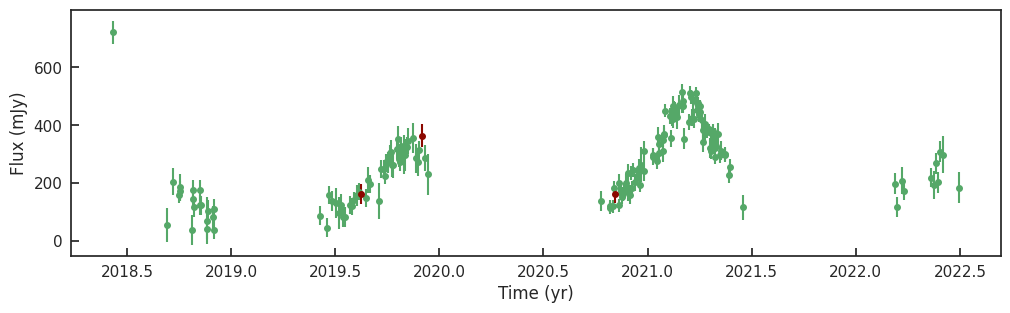

In [71]:
# create request to ACTeroids container
asteroid = 'Vesta'
array = 'pa5'
frequency = '150'

name = f'{asteroid}_lc_{array}_{frequency}' # this is the final format of the string

s3_path = 's3://cornell-acteroids/' + name + '.fits'

try:
    with fits.open(s3_path, fsspec_kwargs={"anon": True}) as hdul:  
        data = hdul[1].data
except PermissionError:
    raise FileNotFoundError(f"Could not find the file at {s3_path}. This file path does not exist.")

# get data from each column
times = data['Time']
flux = data['Flux']
error = data['FluxUncertainty']
weight = data['Weight']

# convert from Unix to years
t = Time(times, format="unix")
years = t.decimalyear

# create and display scatter plot with error bars
fig = plt.figure(figsize=(12, 8))

# Bottom plot - spans all 3 columns
ax_lc = plt.subplot2grid((2, 3), (1, 0), colspan=3)

color=sns.color_palette("deep")[2] 
stamp_color = sns.color_palette("dark")[3]
ax_lc.errorbar(years[1:14], flux[1:14], yerr=error[1:14], fmt='o', markersize=4, color=color)
ax_lc.errorbar(years[16:56], flux[16:56], yerr=error[16:56], fmt='o', markersize=4, color=color)
ax_lc.errorbar(years[58:], flux[58:], yerr=error[58:], fmt='o', markersize=4, color=color)
ax_lc.errorbar(years[0], flux[0], yerr=error[0], fmt='o', markersize=4, color=stamp_color)
ax_lc.errorbar(years[15], flux[15], yerr=error[15], fmt='o', markersize=4, color=stamp_color)
ax_lc.errorbar(years[57], flux[57], yerr=error[57], fmt='o', markersize=4, color=stamp_color)
ax_lc.tick_params(direction='in')
ax_lc.set_xlabel('Time (yr)')
ax_lc.set_ylabel('Flux (mJy)');
fig.savefig('Vesta_lcurve_fig1.pdf')

# Figure 2

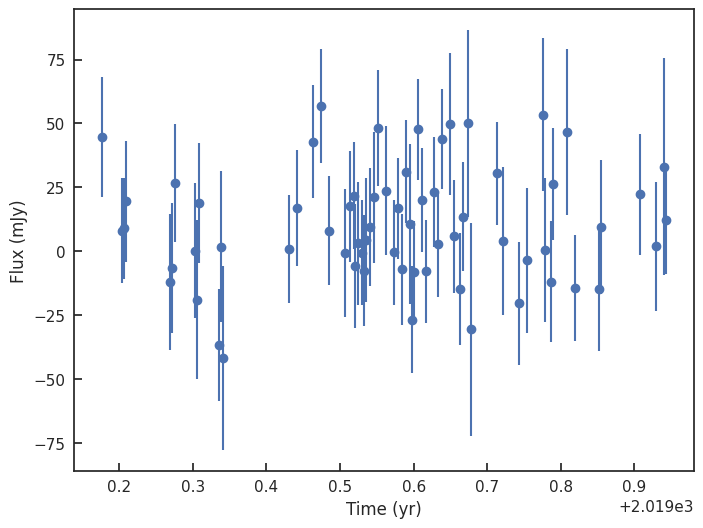

In [72]:
# create request to ACTeroids container
asteroid = 'Erminia'
array = 'pa6'
frequency = '090'

name = f'{asteroid}_lc_{array}_{frequency}' # this is the final format of the string

s3_path = 's3://cornell-acteroids/' + name + '.fits'

try:
    with fits.open(s3_path, fsspec_kwargs={"anon": True}) as hdul:  
        data = hdul[1].data
except PermissionError:
    raise FileNotFoundError(f"Could not find the file at {s3_path}. This file path does not exist.")

# get data from each column
times = data['Time']
flux = data['Flux']
error = data['FluxUncertainty']
weight = data['Weight']

# convert from Unix to years
t = Time(times, format="unix")
years = t.decimalyear

# create and display scatter plot with error bars
plt.errorbar(years, flux, yerr=error, fmt='o')
plt.tick_params(direction='in')
plt.xlabel('Time (yr)')
plt.ylabel('Flux (mJy)')
plt.savefig('Erminia_lcurve_fig2.pdf')
plt.show()